<a href="https://colab.research.google.com/github/DulithMH/-Titanic-Survival-Prediction-Model-Comparison/blob/main/complete_Python_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import xgboost as xgb

In [2]:
pip install xgboost

2️⃣ Load Dataset

In [4]:
import requests
import os

# Check if the file already exists to avoid re-downloading
if not os.path.exists('titanic.csv'):
    url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
    response = requests.get(url)
    response.raise_for_status() # Raise an exception for HTTP errors
    with open('titanic.csv', 'wb') as f:
        f.write(response.content)
    print("titanic.csv downloaded successfully.")
else:
    print("titanic.csv already exists.")

df = pd.read_csv("titanic.csv")
df.head()

titanic.csv downloaded successfully.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


3️⃣ Data Preprocessing

Convert categorical variables.

In [5]:
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

In [6]:
df = df.dropna()

4️⃣ Define Features and Target

In [7]:
X = df[['Pclass','Sex','Age','Fare']]
y = df['Survived']

5️⃣ Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

6️⃣ Logistic Regression

In [9]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.7567567567567568


7️⃣ Decision Tree

In [10]:
dt = DecisionTreeClassifier(max_depth=3)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

Decision Tree Accuracy: 0.7837837837837838


8️⃣ Random Forest

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.8108108108108109


9️⃣ XGBoost

In [12]:
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.7027027027027027


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:36:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔟 Compare All Models

In [13]:
results = pd.DataFrame({
    "Model": ["Logistic Regression","Decision Tree","Random Forest","XGBoost"],
    "Accuracy": [lr_acc, dt_acc, rf_acc, xgb_acc]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.756757
1        Decision Tree  0.783784
2        Random Forest  0.810811
3              XGBoost  0.702703


1️⃣1️⃣ Plot Model Comparison (for your article)

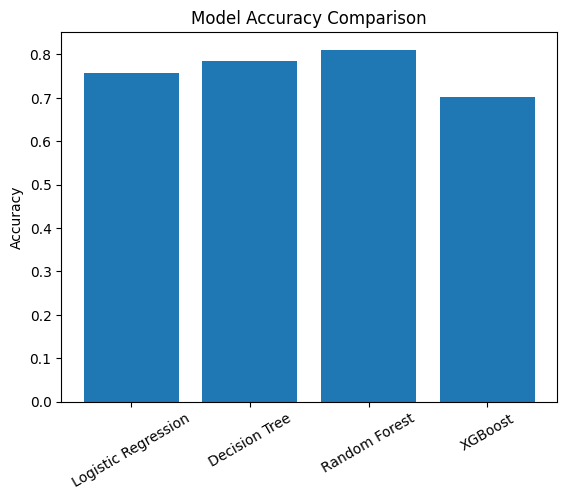

In [14]:
import matplotlib.pyplot as plt

plt.bar(results["Model"], results["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)

plt.show()

1️⃣2️⃣ Optional: Confusion Matrix

In [15]:
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

[[12  3]
 [ 4 18]]
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        15
           1       0.86      0.82      0.84        22

    accuracy                           0.81        37
   macro avg       0.80      0.81      0.81        37
weighted avg       0.81      0.81      0.81        37

